# Analyse exploratoireRH - Turnover des employés

Ce notebook a pour objectif d'analyser les facteurs associés au départ des employés à partir du dataset nettoyé.

Les principales questions étudiées sont :

- Quel est le taux global d'attrition ?
- Quels départements sont les plus touchés ?
- Les heures supplémentaires sont-elles liées aux départs ?
- La satisfaction au travail influence-t-elle le turnover ?
- L'ancienneté, l'âge ou le salaire semblent-ils jouer un rôle ?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
data_path = Path("../data/processed/employee_attrition_clean.csv")
df = pd.read_csv(data_path)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0


In [4]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 1470
Nombre de colonnes : 32


## 1. KPI globaux RH

In [6]:
total_employees = df.shape[0]
employees_left = df["Attrition_Flag"].sum()
employees_stayed = total_employees - employees_left
attrition_rate = df["Attrition_Flag"].mean() * 100
average_age = df["Age"].mean()
average_income = df["MonthlyIncome"].mean()
average_years_company = df["YearsAtCompany"].mean()

print(f"Nombre total d'employés : {total_employees}")
print(f"Employés partis : {employees_left}")
print(f"Employés restés : {employees_stayed}")
print(f"Taux d'attrition : {attrition_rate:.2f}%")
print(f"Age moyen : {average_age:.1f} ans")
print(f"Salaire mensuel moyen : {average_income:.0f}")
print(f"Ancienneté moyenne : {average_years_company:.1f} ans")

Nombre total d'employés : 1470
Employés partis : 237
Employés restés : 1233
Taux d'attrition : 16.12%
Age moyen : 36.9 ans
Salaire mensuel moyen : 6503
Ancienneté moyenne : 7.0 ans


## 2. Répartition globale de l'attrition

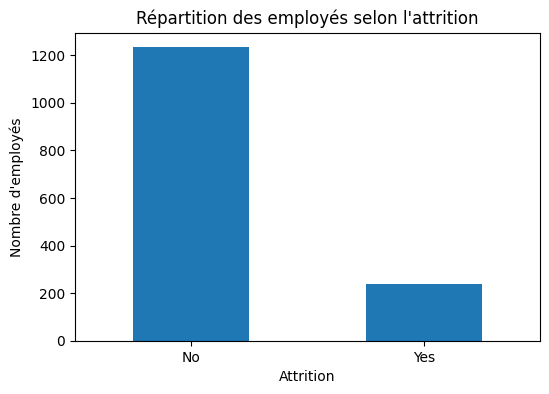

In [7]:
attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(6, 4))
attrition_counts.plot(kind="bar")
plt.title("Répartition des employés selon l'attrition")
plt.xlabel("Attrition")
plt.ylabel("Nombre d'employés")
plt.xticks(rotation=0)
plt.show()

In [9]:
def attrition_rate_by_category(data, column):
    result = (
        data.groupby(column)["Attrition_Flag"]
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
        .reset_index()
    )

    result = result.rename(columns={"Attrition_Flag": "Attrition_Rate"})

    return result

## 3. Taux d'attrition par département

In [11]:
attrition_by_department = attrition_rate_by_category(df, "Department")
attrition_by_department

,Department,Attrition_Rate
0,Sales,20.63
1,Human Resources,19.05
2,Research & Development,13.84


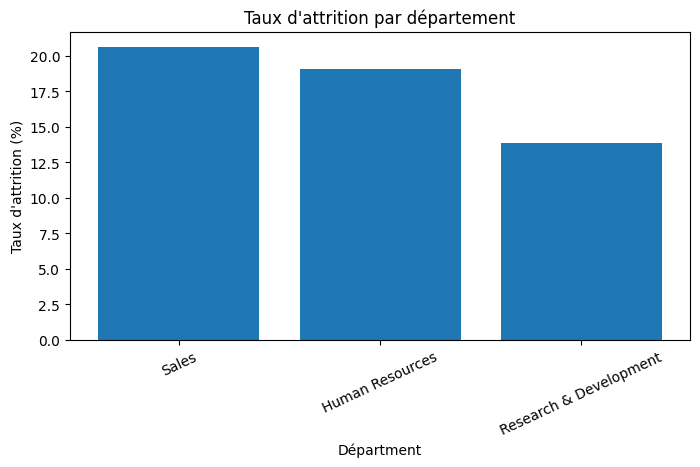

In [12]:
plt.figure(figsize=(8, 4))
plt.bar(attrition_by_department["Department"], attrition_by_department["Attrition_Rate"])
plt.title("Taux d'attrition par département")
plt.xlabel("Départment")
plt.ylabel("Taux d'attrition (%)")
plt.xticks(rotation=25)
plt.show()

Le taux d'attrition varie selon les départements. Cette différence peut indiquer que certains services sont davantage exposés au turnover, possiblement en raison de la charge de travail, du type de poste ou des conditions internes.

## 4. Impact des heures supplémentaires

In [13]:
attrition_by_overtime = attrition_rate_by_category(df, "OverTime")
attrition_by_overtime

,OverTime,Attrition_Rate
0,Yes,30.53
1,No,10.44


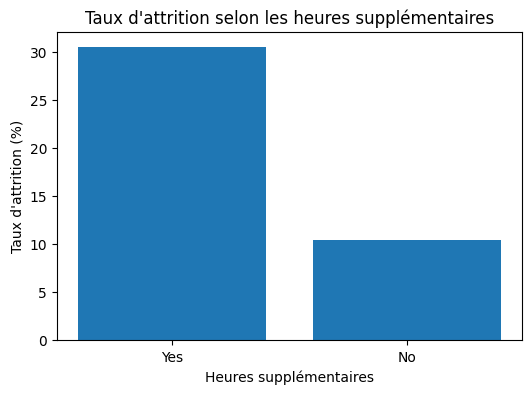

In [14]:
plt.figure(figsize=(6, 4))
plt.bar(attrition_by_overtime["OverTime"], attrition_by_overtime["Attrition_Rate"])
plt.title("Taux d'attrition selon les heures supplémentaires")
plt.xlabel("Heures supplémentaires")
plt.ylabel("Taux d'attrition (%)")
plt.xticks(rotation=0)
plt.show()

## 5. Taux d'attrition par poste

In [15]:
attrition_by_jobrole = attrition_rate_by_category(df, "JobRole")
attrition_by_jobrole

,JobRole,Attrition_Rate
0,Sales Representative,39.76
1,Laboratory Technician,23.94
2,Human Resources,23.08
3,Sales Executive,17.48
4,Research Scientist,16.10
5,Manufacturing Director,6.90
6,Healthcare Representative,6.87
7,Manager,4.90
8,Research Director,2.50


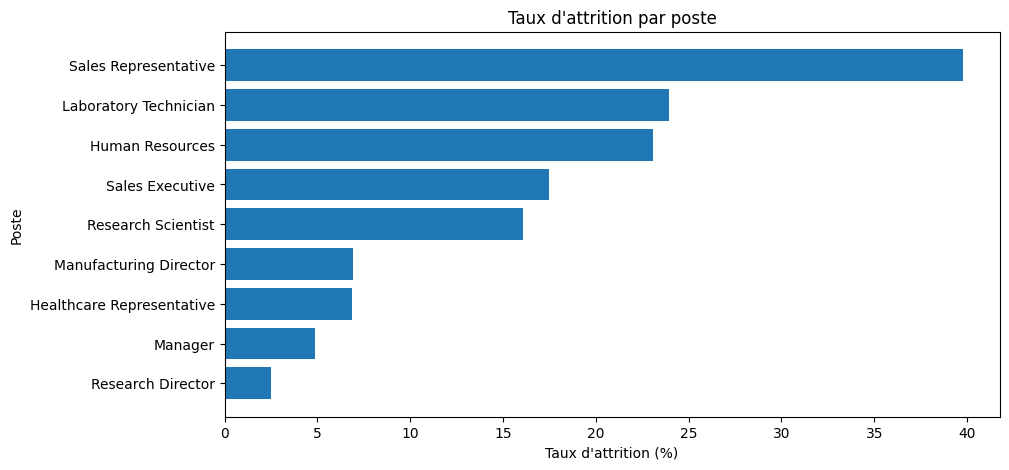

In [16]:
plt.figure(figsize=(10, 5))
plt.barh(attrition_by_jobrole["JobRole"], attrition_by_jobrole["Attrition_Rate"])
plt.title("Taux d'attrition par poste")
plt.xlabel("Taux d'attrition (%)")
plt.ylabel("Poste")
plt.gca().invert_yaxis()
plt.show()

## 6. Attrition selon la satisfaction au travail

In [17]:
attrition_by_job_satisfaction = attrition_rate_by_category(df, "JobSatisfaction")
attrition_by_job_satisfaction

,JobSatisfaction,Attrition_Rate
0,1,22.84
1,3,16.52
2,2,16.43
3,4,11.33


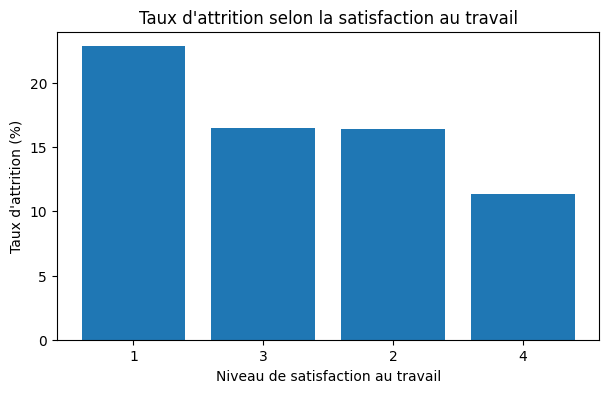

In [18]:
plt.figure(figsize=(7, 4))
plt.bar(
    attrition_by_job_satisfaction["JobSatisfaction"].astype(str),
    attrition_by_job_satisfaction["Attrition_Rate"]
)
plt.title("Taux d'attrition selon la satisfaction au travail")
plt.xlabel("Niveau de satisfaction au travail")
plt.ylabel("Taux d'attrition (%)")
plt.show()

Le taux d'attrition est généralement plus élevé chez les employés ayant une satisfaction plus faible. Cela confirme l'importance de suivre régulièrement les indicateurs d'engagement et de satisfaction interne.

## 7. Attrition selon l'équilibre vie professionnelle / personnelle

In [19]:
attrition_by_worklife = attrition_rate_by_category(df, "WorkLifeBalance")
attrition_by_worklife

,WorkLifeBalance,Attrition_Rate
0,1,31.25
1,4,17.65
2,2,16.86
3,3,14.22


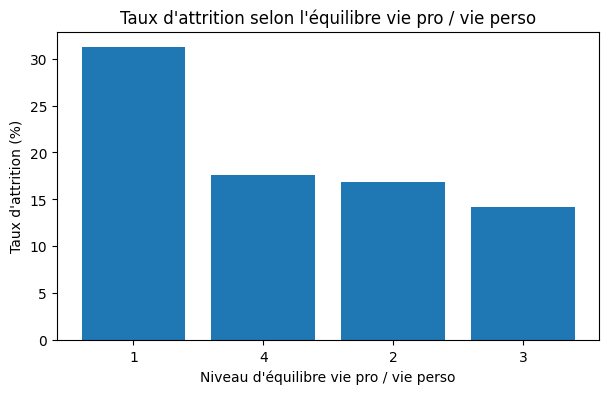

In [20]:
plt.figure(figsize=(7, 4))
plt.bar(
    attrition_by_worklife["WorkLifeBalance"].astype(str),
    attrition_by_worklife["Attrition_Rate"]
)
plt.title("Taux d'attrition selon l'équilibre vie pro / vie perso")
plt.xlabel("Niveau d'équilibre vie pro / vie perso")
plt.ylabel("Taux d'attrition (%)")
plt.show()

## 8. Attrition selon l'ancienneté

In [21]:
df["YearsAtCompany_Group"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 1, 3, 5, 10, 40],
    labels=["0-1 an", "2-3 ans", "4-5 ans", "6-10 ans", "10+ ans"]
)

attrition_by_years = attrition_rate_by_category(df, "YearsAtCompany_Group")

attrition_by_years

,YearsAtCompany_Group,Attrition_Rate
0,0-1 an,34.88
1,2-3 ans,18.43
2,4-5 ans,13.07
3,6-10 ans,12.28
4,10+ ans,8.13


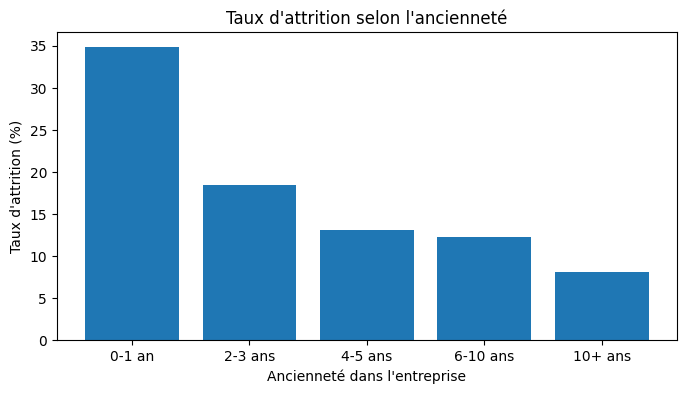

In [22]:
plt.figure(figsize=(8, 4))
plt.bar(
    attrition_by_years["YearsAtCompany_Group"].astype(str),
    attrition_by_years["Attrition_Rate"]
)
plt.title("Taux d'attrition selon l'ancienneté")
plt.xlabel("Ancienneté dans l'entreprise")
plt.ylabel("Taux d'attrition (%)")
plt.show()

## 9. Salaire mensuel moyen selon l'attrition

In [23]:
income_by_attrition = df.groupby("Attrition")["MonthlyIncome"].mean().round(0)
income_by_attrition

Attrition
No     6833.0
Yes    4787.0
Name: MonthlyIncome, dtype: float64

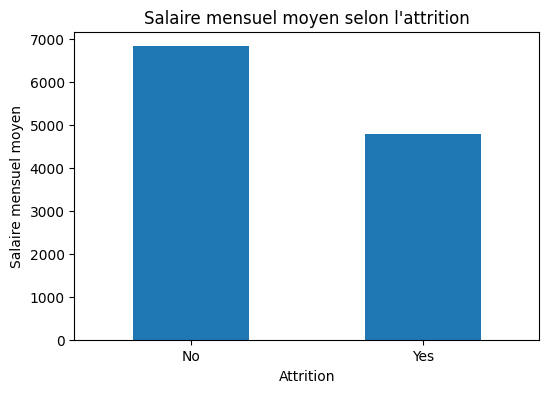

In [24]:
plt.figure(figsize=(6, 4))
income_by_attrition.plot(kind="bar")
plt.title("Salaire mensuel moyen selon l'attrition")
plt.xlabel("Attrition")
plt.ylabel("Salaire mensuel moyen")
plt.xticks(rotation=0)
plt.show()

La comparaison du salaire moyen entre les employés restés et partis permet d'évaluer si la rémunération semble être un facteur associé au turnover. Cette analyse doit être interprétée avec prudence, car le salaire dépend aussi fortement du poste, de l'ancienneté et du niveau hiérarchique.

## 10. Attrition selon l'âge

In [25]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)

attrition_by_age = attrition_rate_by_category(df, "Age_Group")
attrition_by_age

,Age_Group,Attrition_Rate
0,18-25,35.77
1,26-35,19.14
2,56+,17.02
3,46-55,11.50
4,36-45,9.19


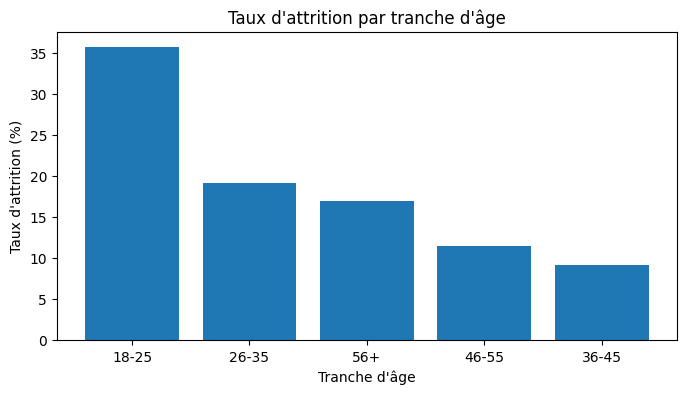

In [26]:
plt.figure(figsize=(8, 4))
plt.bar(
    attrition_by_age["Age_Group"].astype(str),
    attrition_by_age["Attrition_Rate"]
)
plt.title("Taux d'attrition par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Taux d'attrition (%)")
plt.show()

## 11. Synthèse des premiers constats

In [27]:
summary_tables = {
    "Département": attrition_by_department,
    "Heures supplémentaires": attrition_by_overtime,
    "Poste": attrition_by_jobrole.head(5),
    "Satisfaction au travail": attrition_by_job_satisfaction,
    "Équilibre vie pro/perso": attrition_by_worklife,
    "Ancienneté": attrition_by_years,
    "Âge": attrition_by_age
}

for name, table in summary_tables.items():
    print(f"\n{name}")
    display(table)


Département


,Department,Attrition_Rate
0,Sales,20.63
1,Human Resources,19.05
2,Research & Development,13.84



Heures supplémentaires


,OverTime,Attrition_Rate
0,Yes,30.53
1,No,10.44



Poste


...

,WorkLifeBalance,Attrition_Rate
0,1,31.25
1,4,17.65
2,2,16.86
3,3,14.22



Ancienneté


,YearsAtCompany_Group,Attrition_Rate
0,0-1 an,34.88
1,2-3 ans,18.43
2,4-5 ans,13.07
3,6-10 ans,12.28
4,10+ ans,8.13



Âge


,Age_Group,Attrition_Rate
0,18-25,35.77
1,26-35,19.14
2,56+,17.02
3,46-55,11.50
4,36-45,9.19


## Conclusion intermédiaire

Cette première analyse exploratoire met en évidence plusieurs dimensions importantes du turnover :

- le taux d'attrition global permet de mesurer l'ampleur du phénomène ;
- les départs varient selon le département et le poste ;
- les heures supplémentaires semblent être un facteur important à surveiller ;
- la satisfaction au travail et l'équilibre vie professionnelle / personnelle peuvent influencer le risque de départ ;
- l'ancienneté et l'âge permettent d'identifier certains profils potentiellement plus exposés.

Ces constats devront être approfondis dans la suite du projet avec une analyse statistique plus structurée et un modèle prédictif simple.